# Part 1: The Wind Resource [40 pts]

Site: **54.091 N, 3.741 W** — Irish Sea, off the Cumbria coast, UK.

Data: hourly wind speed at 10 m height for 2025, downloaded from [NASA POWER](https://power.larc.nasa.gov/). Save the raw download to `data/wind/` (kept out of git via `.gitignore`; see `data/wind/README.md` for the exact site/parameters to re-download).

In [4]:
import sys
sys.path.append("../../src")  # lets `import windtools` work with plain python, no install needed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from windtools import weibull

# NASA POWER hourly exports have a ~10-line metadata header before the actual data
df = pd.read_csv("../../data/wind/POWER_Point_Hourly_20250101_20251231_054d09N_003d74W_LST.csv", skiprows=10)
wind_10m = df["WS10M"].to_numpy()

## Normalized histogram / PDF, mean and standard deviation [10 pts]

U = 6.903 m/s, std dev = 3.428 m/s


Text(0.5, 1.0, 'Wind speed PDF at 10 m — 2025')

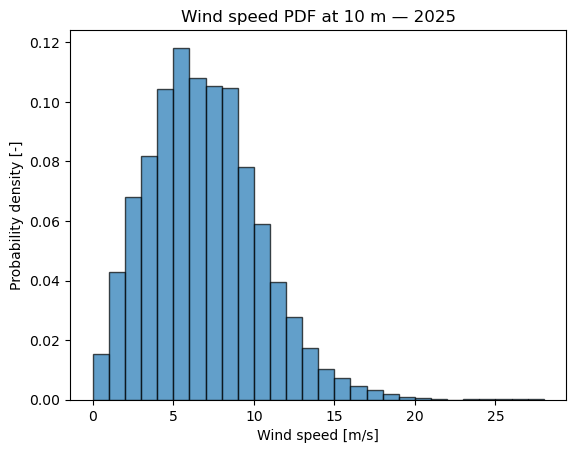

In [5]:
U = wind_10m.mean()
sigma = wind_10m.std(ddof=1)
print(f"U = {U:.3f} m/s, std dev = {sigma:.3f} m/s")

bins = np.arange(0, wind_10m.max() + 1, 1)
plt.hist(wind_10m, bins=bins, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("Wind speed [m/s]"); plt.ylabel("Probability density [-]")
plt.title("Wind speed PDF at 10 m — 2025")

## Weibull parameters via the graphical (least-squares) method [20 pts]

See Appendix 1 of the assignment. `windtools.weibull.fit_weibull_lsq` implements this.

k = 2.062, c = 7.826 m/s, R^2 = 0.9980


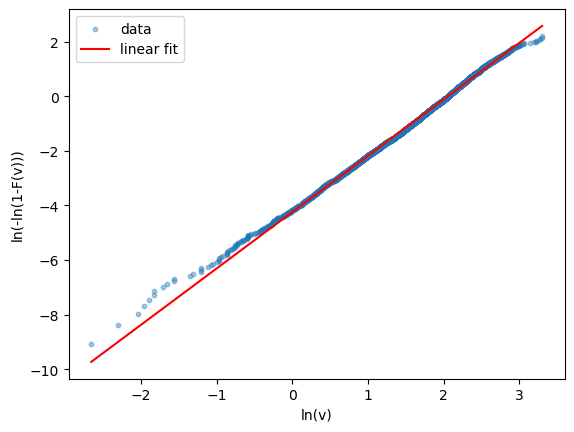

In [6]:
k, c, r2, x, y = weibull.fit_weibull_lsq(wind_10m)
print(f"k = {k:.3f}, c = {c:.3f} m/s, R^2 = {r2:.4f}")

plt.scatter(x, y, s=10, alpha=0.4, label="data")
plt.plot(x, k * x - k * np.log(c), color="red", label="linear fit")
plt.xlabel("ln(v)"); plt.ylabel("ln(-ln(1-F(v)))"); plt.legend()

## Weibull fit overlaid on histogram + RMSE [5 pts]

RMSE = 0.00455


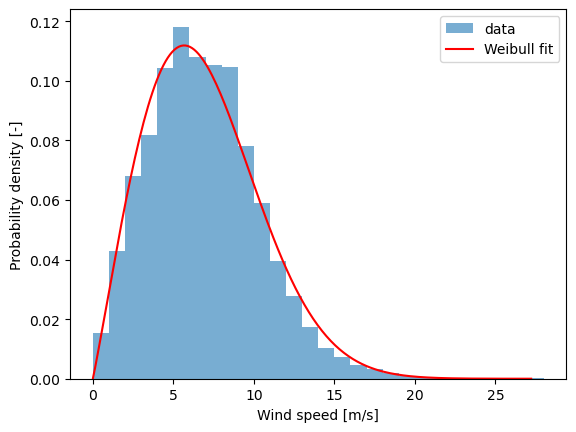

In [7]:
v_range = np.linspace(0.01, wind_10m.max(), 200)
plt.hist(wind_10m, bins=np.arange(0, wind_10m.max() + 1, 1), density=True, alpha=0.6, label="data")
plt.plot(v_range, weibull.weibull_pdf(v_range, k, c), color="red", label="Weibull fit")
plt.xlabel("Wind speed [m/s]"); plt.ylabel("Probability density [-]"); plt.legend()

rmse = weibull.rmse_pdf(wind_10m, k, c, bin_width=1.0)
print(f"RMSE = {rmse:.5f}")

## Reflection [5 pts]

TODO: short written interpretation of the results for your site.